<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
from google.colab import drive
import pandas as pd
# Monter Google Drive
drive.mount('/content/drive')
# Définir le chemin du dossier
path = "/content/drive/MyDrive/Colab Notebooks/"

Mounted at /content/drive


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv(path +"population.csv")

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv(path +'dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv(path +'aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv(path +'sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", population.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Types de données :\n", population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs par colonne :\n", population.count())

Nombre de colonnes : 3 

Types de données :
 Zone       object
Année       int64
Valeur    float64
dtype: object

Nombre de valeurs par colonne :
 Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [5]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population["Valeur"] = population["Valeur"] * 1000

In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={"Valeur": "Population"}, inplace=True)

In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [10]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", dispo_alimentaire.shape[1])

Nombre de colonnes : 18


In [11]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
colonnes_milliers_tonnes = [
   "Aliments pour animaux",
   "Autres Utilisations",
    "Disponibilité intérieure",
    "Exportations - Quantité",
    "Importations - Quantité",
    "Nourriture",
    "Pertes",
    "Production",
    "Semences",
    "Traitement",
    "Variation de stock"
]
dispo_alimentaire[colonnes_milliers_tonnes]=dispo_alimentaire[colonnes_milliers_tonnes]*1_000_000

In [14]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [16]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", aide_alimentaire.shape[1])

Nombre de colonnes : 4


In [17]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'},inplace=True)

In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur']=aide_alimentaire['Valeur'] * 1_000

In [20]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [22]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", sous_nutrition.shape[1])

Nombre de colonnes : 3


In [23]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = sous_nutrition['Valeur'].fillna(0)

In [25]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={'Valeur':'Sous_nutrition'},inplace=True)
sous_nutrition.head()

,Zone,Année,Sous_nutrition
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [26]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['Sous_nutrition']=sous_nutrition['Sous_nutrition']*1_000_000

In [27]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [28]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# fonction retourne true or false pour verifier si 2017 est comprise dans l'intervalle
def contient_2017(intervalle):
    debut, fin = intervalle.split('-')
    return int(debut) < 2017 < int(fin)

# Filtrer les lignes où l'année 2017 est incluse
sous_2017 = sous_nutrition[sous_nutrition['Année'].apply(contient_2017)].copy()
# Ajouter une vraie colonne 'Année' = 2017
sous_2017['Année'] = 2017

In [29]:
#Affichage du dataset
sous_2017.head()

,Zone,Année,Sous_nutrition
4,Afghanistan,2017,10500000.0
10,Afrique du Sud,2017,3100000.0
16,Albanie,2017,100000.0
22,Algérie,2017,1300000.0
28,Allemagne,2017,0.0


In [30]:
#Jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
jointure_pop_sous_nutrition=pd.merge(population,sous_2017,on=['Zone','Année'],how='inner')
jointure_pop_sous_nutrition.head()

,Zone,Année,Population,Sous_nutrition
0,Afghanistan,2017,36296113.0,10500000.0
1,Afrique du Sud,2017,57009756.0,3100000.0
2,Albanie,2017,2884169.0,100000.0
3,Algérie,2017,41389189.0,1300000.0
4,Allemagne,2017,82658409.0,0.0


In [31]:
#Calcul et affichage du pourcentage de personne en état de sous nutrition
jointure_pop_sous_nutrition['Proportion_sous_nutrition']=jointure_pop_sous_nutrition['Sous_nutrition']*100/jointure_pop_sous_nutrition['Population']
jointure_pop_sous_nutrition.head()

,Zone,Année,Population,Sous_nutrition,Proportion_sous_nutrition
0,Afghanistan,2017,36296113.0,10500000.0,28.928718
1,Afrique du Sud,2017,57009756.0,3100000.0,5.437666
2,Albanie,2017,2884169.0,100000.0,3.467203
3,Algérie,2017,41389189.0,1300000.0,3.140917
4,Allemagne,2017,82658409.0,0.0,0.000000


In [32]:
#la population totale mondiale est de :
Pop_mondiale=jointure_pop_sous_nutrition['Population'].sum()
Pop_mondiale_sousnut=jointure_pop_sous_nutrition['Sous_nutrition'].sum()
Proportion_sous_nutrition=round(Pop_mondiale_sousnut*100/Pop_mondiale,2)
print('a population totale mondiale est de ',Pop_mondiale,'habitants')
print('a population totale mondiale en état de sous nutrition est de ',Pop_mondiale_sousnut,'habitants')
print('La proportion de personne en sous nutrition est ',Proportion_sous_nutrition,'%')

a population totale mondiale est de  7543798779.0 habitants
a population totale mondiale en état de sous nutrition est de  535700000.0 habitants
La proportion de personne en sous nutrition est  7.1 %


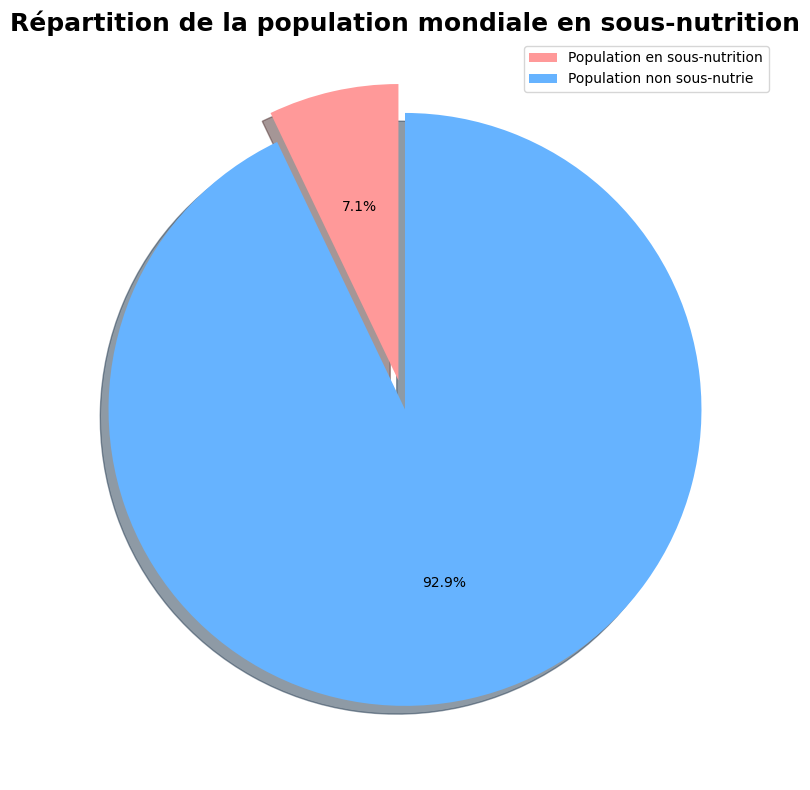

In [33]:
import matplotlib.pyplot as plt
labels = ['Population en sous-nutrition', 'Population non sous-nutrie']
sizes = [Proportion_sous_nutrition, 100 - Proportion_sous_nutrition]
colors = ['#ff9999', '#66b3ff']
# Création du graphique en secteur
plt.figure(figsize=(8,8))
plt.pie(x=sizes, colors=colors,autopct='%.1f%%', explode = (0.1, 0),shadow=True,startangle=90,)
plt.legend(labels)
plt.title("Répartition de la population mondiale en sous-nutrition", fontsize=18,fontweight='bold')
plt.tight_layout() #ajuste automatiquement les marges autour des éléments.
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [34]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dispo_alimentaire['Année']=2017
jointure_dispo_pop_I=pd.merge(dispo_alimentaire,jointure_pop_sous_nutrition,on=['Zone','Année'])

jointure_dispo_pop=jointure_dispo_pop_I.groupby('Zone', as_index=False).agg({
    'Disponibilité alimentaire (Kcal/personne/jour)': 'sum',
    'Sous_nutrition': 'first',
   'Population': 'first'                  # ⚠️ ne pas sommer !
})
#Affichage du nouveau dataframe
jointure_dispo_pop.head()

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Sous_nutrition,Population
0,Afghanistan,2087.0,10500000.0,36296113.0
1,Afrique du Sud,3020.0,3100000.0,57009756.0
2,Albanie,3188.0,100000.0,2884169.0
3,Algérie,3293.0,1300000.0,41389189.0
4,Allemagne,3503.0,0.0,82658409.0


In [35]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
jointure_dispo_pop['dispo_kcal_mondiale']=jointure_dispo_pop['Disponibilité alimentaire (Kcal/personne/jour)']*jointure_dispo_pop['Population']
#Calcul du nombre d'humains pouvant être nourris
#PAR JOUR 1personne à besoins de 2500 Kcal/jour
jointure_dispo_pop['Humains_nourris']=jointure_dispo_pop['dispo_kcal_mondiale']/2500
jointure_dispo_pop.head()

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Sous_nutrition,Population,dispo_kcal_mondiale,Humains_nourris
0,Afghanistan,2087.0,10500000.0,36296113.0,7.574999e+10,3.030000e+07
1,Afrique du Sud,3020.0,3100000.0,57009756.0,1.721695e+11,6.886779e+07
2,Albanie,3188.0,100000.0,2884169.0,9.194731e+09,3.677892e+06
3,Algérie,3293.0,1300000.0,41389189.0,1.362946e+11,5.451784e+07
4,Allemagne,3503.0,0.0,82658409.0,2.895524e+11,1.158210e+08


In [36]:
Nombre_humain_nourris=round(jointure_dispo_pop['Humains_nourris'].sum(),2)
print('Nombre de personne qui pourraient être nourries en 2017 est de :',Nombre_humain_nourris,'habitants')

Nombre de personne qui pourraient être nourries en 2017 est de : 8367593850.93 habitants


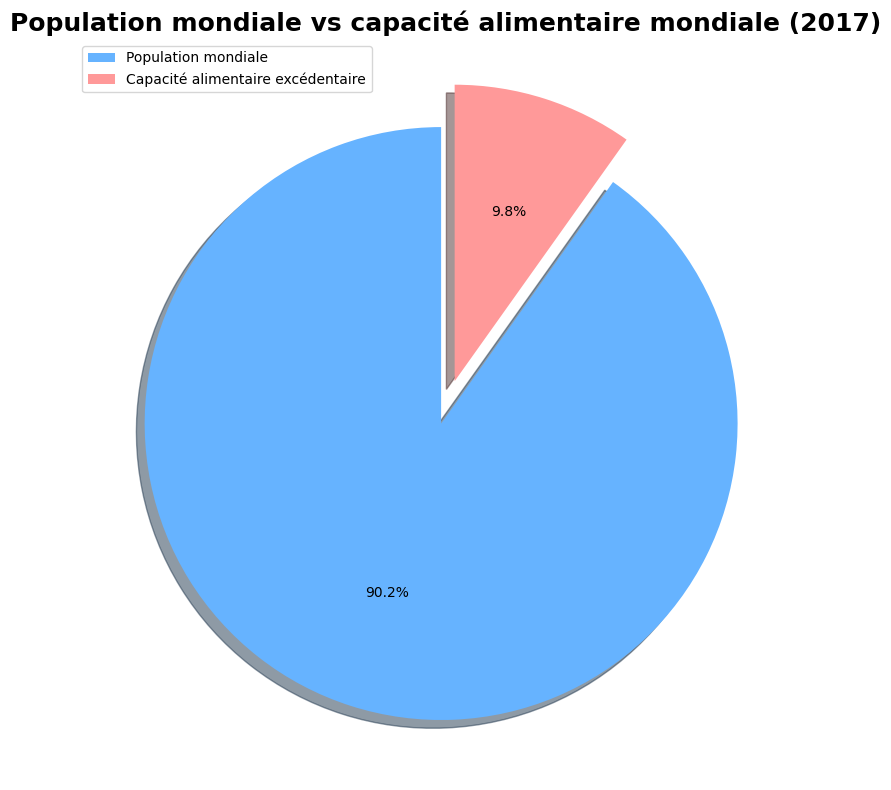

In [37]:
import matplotlib.pyplot as plt
# Calcul de la part excédentaire
Surplus = Nombre_humain_nourris - Pop_mondiale
labels = ['Population mondiale', 'Capacité alimentaire excédentaire']
sizes = [Pop_mondiale, Surplus]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.1)
# Création du graphique en secteur
plt.figure(figsize=(8,8))
plt.pie(sizes,autopct='%1.1f%%',startangle=90,colors=colors,explode=explode,shadow=True)
plt.legend(labels)
plt.title("Population mondiale vs capacité alimentaire mondiale (2017)", fontsize=18,fontweight='bold')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [38]:
#Transfert des données avec les végétaux dans un nouveau dataframe
jointure_dispo_pop_veg = jointure_dispo_pop_I[jointure_dispo_pop_I['Origine'] == 'vegetale']
jointure_dispo_pop_veg=jointure_dispo_pop_veg.groupby('Zone', as_index=False).agg({
    'Origine': 'first',
    'Disponibilité alimentaire (Kcal/personne/jour)': 'sum',
    'Sous_nutrition': 'first',
   'Population': 'first'                  # ⚠️ ne pas sommer !
})
jointure_dispo_pop_veg.head()

,Zone,Origine,Disponibilité alimentaire (Kcal/personne/jour),Sous_nutrition,Population
0,Afghanistan,vegetale,1871.0,10500000.0,36296113.0
1,Afrique du Sud,vegetale,2533.0,3100000.0,57009756.0
2,Albanie,vegetale,2203.0,100000.0,2884169.0
3,Algérie,vegetale,2915.0,1300000.0,41389189.0
4,Allemagne,vegetale,2461.0,0.0,82658409.0


In [39]:
#Calcul du nombre de kcal disponible pour les végétaux
jointure_dispo_pop_veg['dispo_kcal_mondiale']=jointure_dispo_pop_veg['Disponibilité alimentaire (Kcal/personne/jour)']*jointure_dispo_pop_veg['Population']
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
jointure_dispo_pop_veg['Humains_nourris']=jointure_dispo_pop_veg['dispo_kcal_mondiale']/2500
jointure_dispo_pop_veg.head()

,Zone,Origine,Disponibilité alimentaire (Kcal/personne/jour),Sous_nutrition,Population,dispo_kcal_mondiale,Humains_nourris
0,Afghanistan,vegetale,1871.0,10500000.0,36296113.0,6.791003e+10,2.716401e+07
1,Afrique du Sud,vegetale,2533.0,3100000.0,57009756.0,1.444057e+11,5.776228e+07
2,Albanie,vegetale,2203.0,100000.0,2884169.0,6.353824e+09,2.541530e+06
3,Algérie,vegetale,2915.0,1300000.0,41389189.0,1.206495e+11,4.825979e+07
4,Allemagne,vegetale,2461.0,0.0,82658409.0,2.034223e+11,8.136894e+07


In [40]:
Nombre_humain_nourris_veg=round(jointure_dispo_pop_veg['Humains_nourris'].sum(),2)
print('Nombre de personne qui pourraient être nourries uniquement par les végétaux en 2017 est de :',Nombre_humain_nourris_veg,'habitants')

Nombre de personne qui pourraient être nourries uniquement par les végétaux en 2017 est de : 6904305684.6 habitants


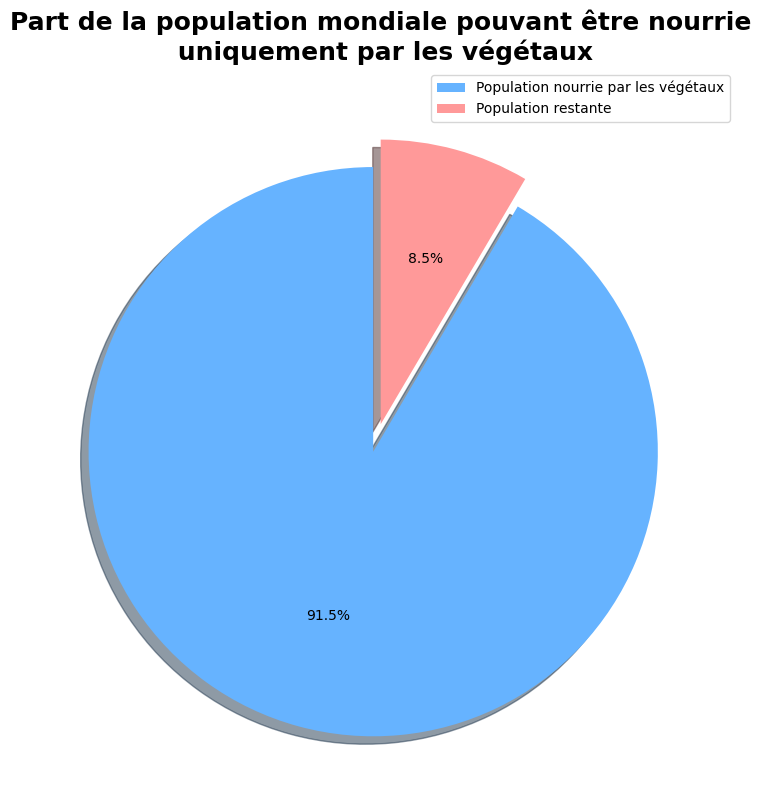

In [41]:
import matplotlib.pyplot as plt
labels = ['Population nourrie par les végétaux', 'Population restante']
sizes = [Nombre_humain_nourris_veg, Pop_mondiale-Nombre_humain_nourris_veg]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)  # met en avant la part végétale
plt.figure(figsize=(8,8))
plt.pie(sizes,autopct='%1.1f%%',startangle=90,colors=colors,explode=explode,shadow=True)
plt.legend(labels)
plt.title("Part de la population mondiale pouvant être nourrie\n uniquement par les végétaux",fontsize=18,fontweight='bold')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [42]:
Total_animal=dispo_alimentaire['Aliments pour animaux'].sum()
Total_autre=dispo_alimentaire['Autres Utilisations'].sum()
Total_Nourriture=dispo_alimentaire['Nourriture'].sum()
Total_Pertes=dispo_alimentaire['Pertes'].sum()
Total_Semences=dispo_alimentaire['Semences'].sum()
Total_Traitement=dispo_alimentaire['Traitement'].sum()
dispo_alimentaire.head()
Total=Total_animal+Total_autre+Total_Nourriture+Total_Pertes+Total_Semences+Total_Traitement


Aliments_pour_animaux=Total_animal*100/Total
print(Aliments_pour_animaux)
Autres_Utilisations=Total_autre*100/Total
print(Autres_Utilisations)
Nourriture=Total_Nourriture*100/Total
print(Nourriture)
Pertes=Total_Pertes*100/Total
print(Pertes)
Semences=Total_Semences*100/Total
print(Semences)
Traitement=Total_Traitement*100/Total
print(Traitement)


13.229526082426375
8.774305702071858
49.46201242530373
4.602056764292508
1.5689968709527689
22.363102154952756


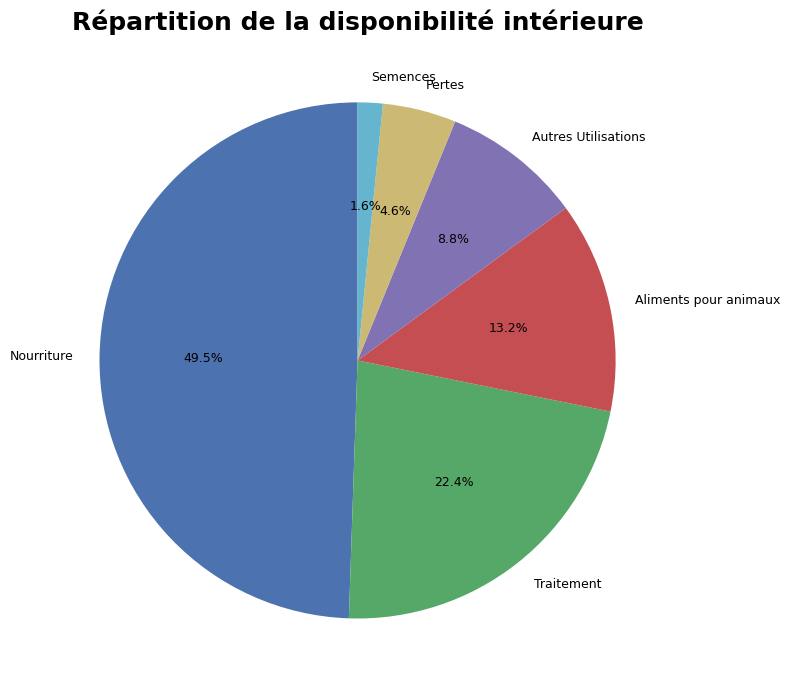

In [43]:
import matplotlib.pyplot as plt
labels=['Aliments pour animaux','Nourriture','Autres Utilisations','Pertes','Semences','Traitement']
sizes=[Aliments_pour_animaux,Nourriture,Autres_Utilisations,Pertes,Semences,Traitement]
couleurs = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD']
#  Trier les valeurs et labels par ordre décroissant
sizes, labels = zip(*sorted(zip(sizes, labels), reverse=True))
plt.figure(figsize=(8,8))
plt.pie(x=sizes,labels=labels,  textprops={'fontsize': 9}, colors=couleurs,autopct='%.1f%%',startangle=90) # rapproche les % du centre)
plt.title("Répartition de la disponibilité intérieure", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [44]:
#Création d'une liste avec toutes les variables
liste_variables = list(jointure_dispo_pop.columns)
print(liste_variables)

['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Sous_nutrition', 'Population', 'dispo_kcal_mondiale', 'Humains_nourris']


In [45]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
# Liste des produits considérés comme céréales
cereales = [
    "Blé",
    "Riz (Eq Blanchi)",
    "Maïs",
    "Orge",
    "Seigle",
    "Avoine",
    "Mil",
    "Sorgho",
    "Céréales, Autres"
]
Df_cereales=dispo_alimentaire.loc[dispo_alimentaire['Produit'].isin(cereales),:]
Df_cereales.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,0.0,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,2017
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2017
32,Afghanistan,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,0.56,3.130000e+08,0.0,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,2017
40,Afghanistan,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,0.79,5.240000e+08,0.0,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,2017
47,Afghanistan,Riz (Eq Blanchi),vegetale,0.0,0.0,141.0,13.82,0.27,2.70,4.610000e+08,0.0,1.190000e+08,4.220000e+08,24000000.0,3.420000e+08,14000000.0,0.0,0.0,2017


In [46]:
#Affichage de la proportion d'alimentation animale
Total_animalc=Df_cereales['Aliments pour animaux'].sum()
Total_autrec=Df_cereales['Autres Utilisations'].sum()
Total_Nourriturec=Df_cereales['Nourriture'].sum()
Total_Pertesc=Df_cereales['Pertes'].sum()
Total_Semencesc=Df_cereales['Semences'].sum()
Total_Traitementc=Df_cereales['Traitement'].sum()
Df_cereales.head()
Totalc=Total_animalc+Total_autrec+Total_Nourriturec+Total_Pertesc+Total_Semencesc+Total_Traitementc


Aliments_pour_animauxc=Total_animalc*100/Totalc
print(Aliments_pour_animauxc)
Autres_Utilisationsc=Total_autrec*100/Totalc
print(Autres_Utilisationsc)
Nourriturec=Total_Nourriturec*100/Totalc
print(Nourriturec)
Pertesc=Total_Pertesc*100/Totalc
print(Pertesc)
Semencesc=Total_Semencesc*100/Totalc
print(Semencesc)
Traitementc=Total_Traitementc*100/Totalc
print(Traitementc)

36.599982503924
9.866398954272997
42.30896051438464
4.409515846566142
2.853879166042808
3.961263014809419


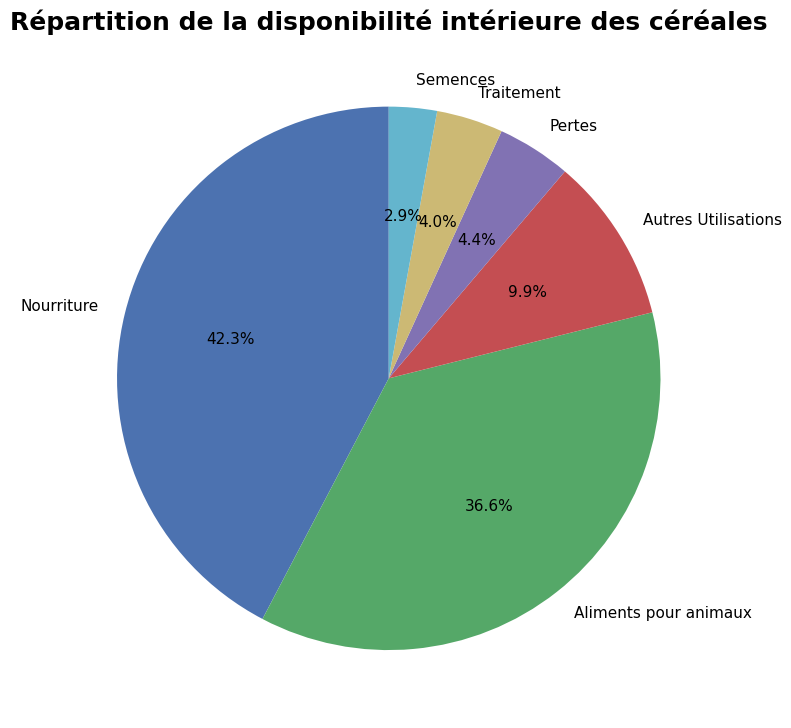

In [47]:
import matplotlib.pyplot as plt
labels=['Aliments pour animaux','Nourriture','Autres Utilisations','Pertes','Semences','Traitement']
sizes=[Aliments_pour_animauxc,Nourriturec,Autres_Utilisationsc,Pertesc,Semencesc,Traitementc]
couleurs = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD']
#  Trier les valeurs et labels par ordre décroissant
sizes, labels = zip(*sorted(zip(sizes, labels), reverse=True))
plt.figure(figsize=(8,8))
plt.pie(x=sizes,labels=labels,textprops={'fontsize': 11}, colors=couleurs,autopct='%.1f%%',startangle=90)
plt.title("Répartition de la disponibilité intérieure des céréales", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [48]:
#affichage après trie des 10 pires pays
jointure_pop_sous_nutrition_pire=jointure_pop_sous_nutrition.sort_values('Proportion_sous_nutrition',ascending=False).reset_index().head(10)
jointure_pop_sous_nutrition_pire=jointure_pop_sous_nutrition_pire.sort_values('Proportion_sous_nutrition').reset_index()
jointure_pop_sous_nutrition_pire.head()

,level_0,index,Zone,Année,Population,Sous_nutrition,Proportion_sous_nutrition
0,9,0,Afghanistan,2017,36296113.0,10500000.0,28.928718
1,8,186,Timor-Leste,2017,1243258.0,400000.0,32.173531
2,7,121,Mozambique,2017,28649018.0,9400000.0,32.810898
3,6,161,Rwanda,2017,11980961.0,4200000.0,35.055619
4,5,183,Tchad,2017,15016753.0,5700000.0,37.957606


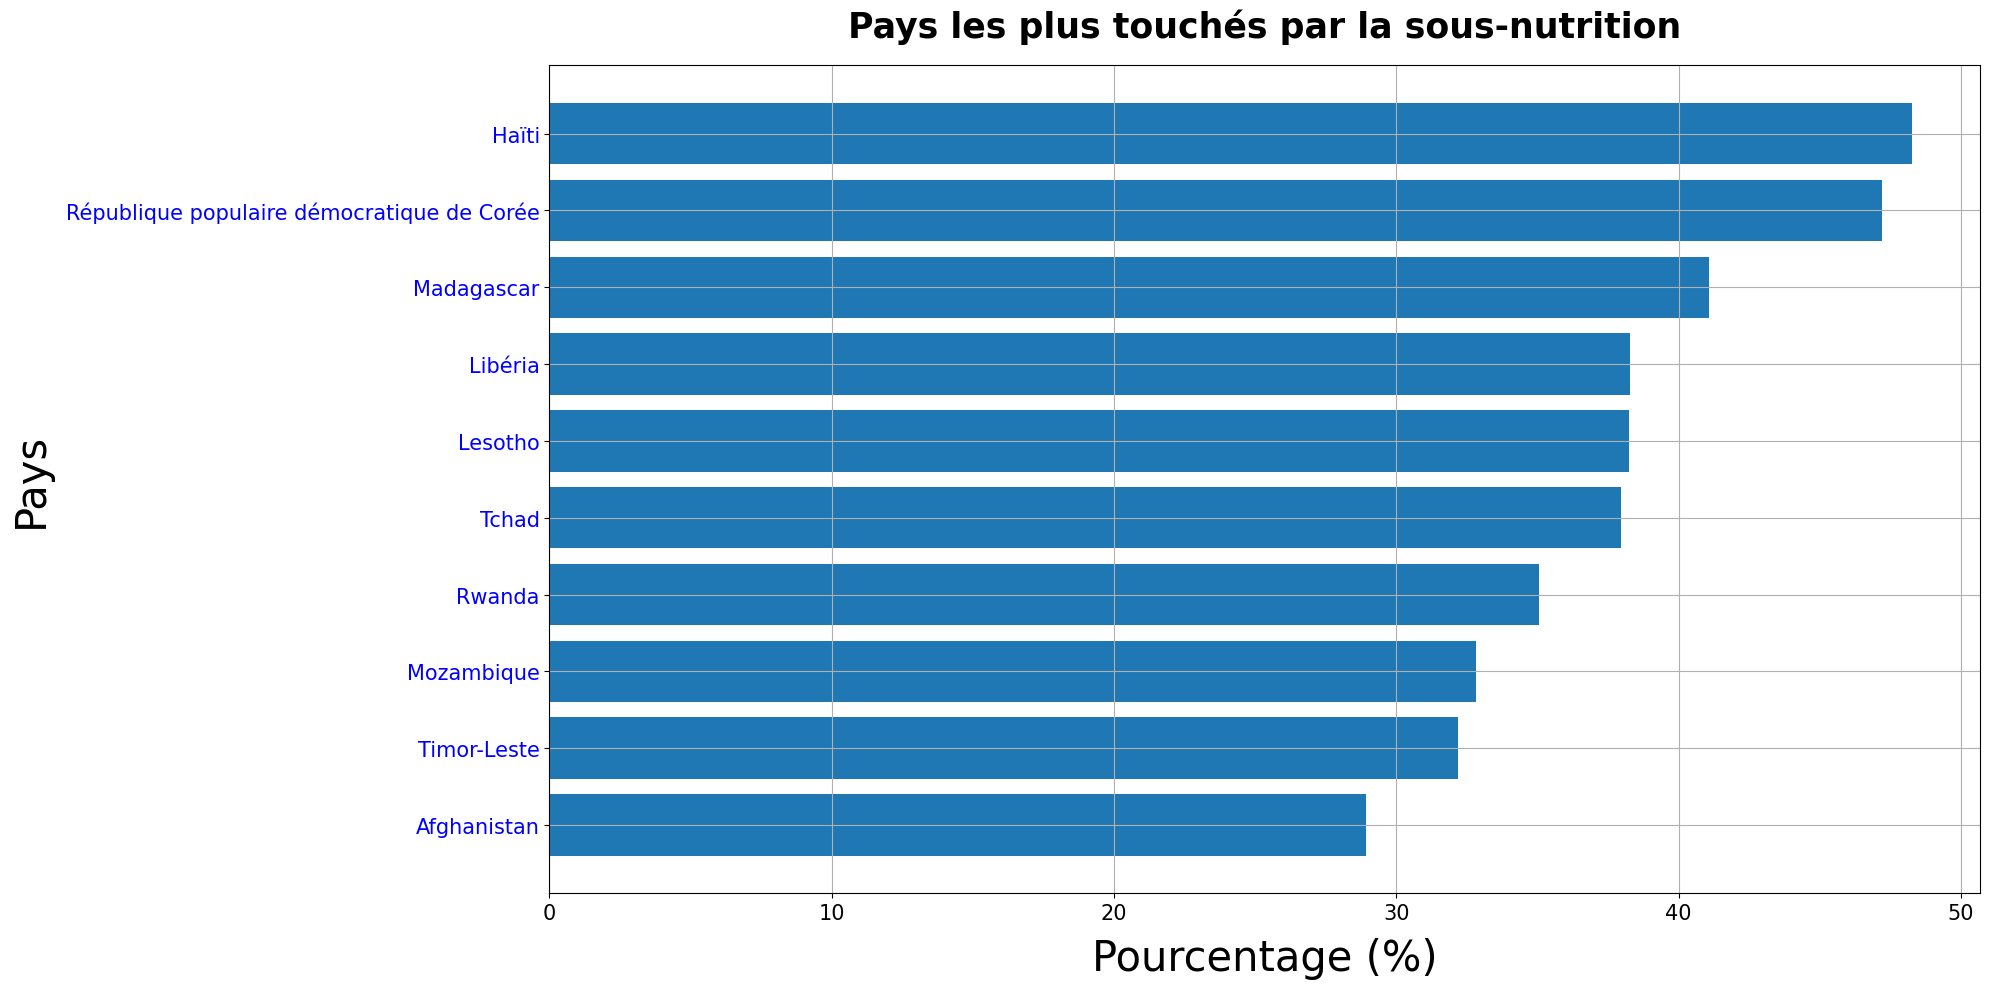

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.barh(width=jointure_pop_sous_nutrition_pire['Proportion_sous_nutrition'],y=jointure_pop_sous_nutrition_pire['Zone'])
plt.xlabel('Pourcentage (%)',fontsize=30,labelpad=10)
plt.ylabel('Pays',fontsize=30,labelpad=10)
plt.xticks( fontsize=15)
plt.yticks(fontsize=15,color='blue')
plt.title("Pays les plus touchés par la sous-nutrition", fontsize=25,pad=20, fontweight='bold')
plt.tight_layout()
plt.grid()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [50]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_pays=aide_alimentaire.groupby('Zone')['Valeur'].sum().reset_index()

In [51]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_alimentaire_pays=aide_alimentaire_pays.sort_values('Valeur',ascending=False).head(10)
aide_alimentaire_pays=aide_alimentaire_pays.sort_values('Valeur').reset_index()
aide_alimentaire_pays


,index,Zone,Valeur
0,43,Niger,276344000
1,53,République démocratique du Congo,288502000
2,59,Somalie,292678000
3,3,Bangladesh,348188000
4,30,Kenya,552836000
5,60,Soudan,669784000
6,61,Soudan du Sud,695248000
7,70,Yémen,1206484000
8,75,Éthiopie,1381294000
9,50,République arabe syrienne,1858943000


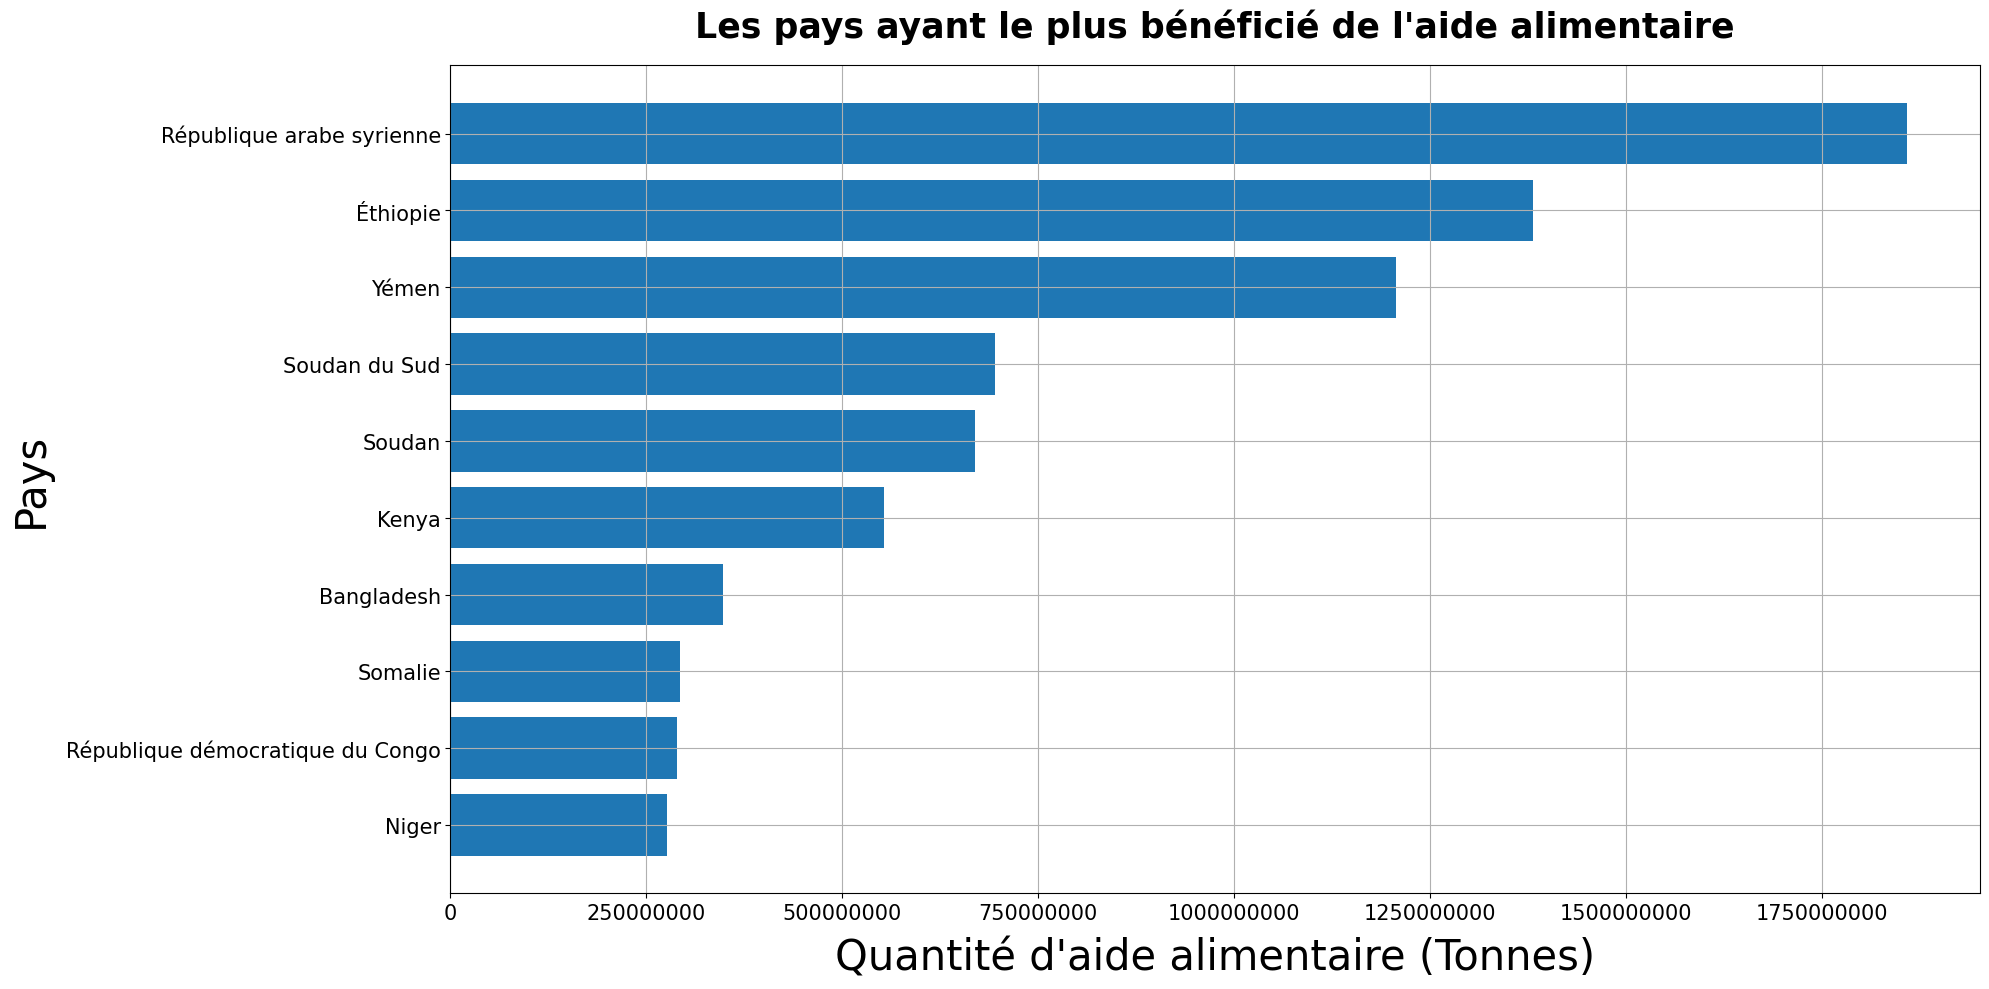

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.barh(width=aide_alimentaire_pays['Valeur'],y=aide_alimentaire_pays['Zone'])
plt.xlabel("Quantité d'aide alimentaire (Tonnes)", fontsize=30,labelpad=10)
plt.ylabel("Pays", fontsize=30,labelpad=10)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("Les pays ayant le plus bénéficié de l'aide alimentaire", fontsize=25,pad=20, fontweight='bold')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='x')
plt.grid()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [53]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
aide_top5Z=aide_alimentaire.groupby('Zone')['Valeur'].sum().sort_values(ascending=False).reset_index().head(5)
aide_top5Z=aide_top5Z['Zone']
aide_top5Z

,Zone
0,République arabe syrienne
1,Éthiopie
2,Yémen
3,Soudan du Sud
4,Soudan


In [54]:
# 2) Filtrer le DataFrame initial avec cette liste
aide_top5 = aide_alimentaire[aide_alimentaire['Zone'].isin(aide_top5Z)]
aide_top5=aide_top5.groupby(['Zone','Année'])['Valeur'].sum().reset_index()
aide_top5.head()

,Zone,Année,Valeur
0,République arabe syrienne,2013,563566000
1,République arabe syrienne,2014,651870000
2,République arabe syrienne,2015,524949000
3,République arabe syrienne,2016,118558000
4,Soudan,2013,330230000


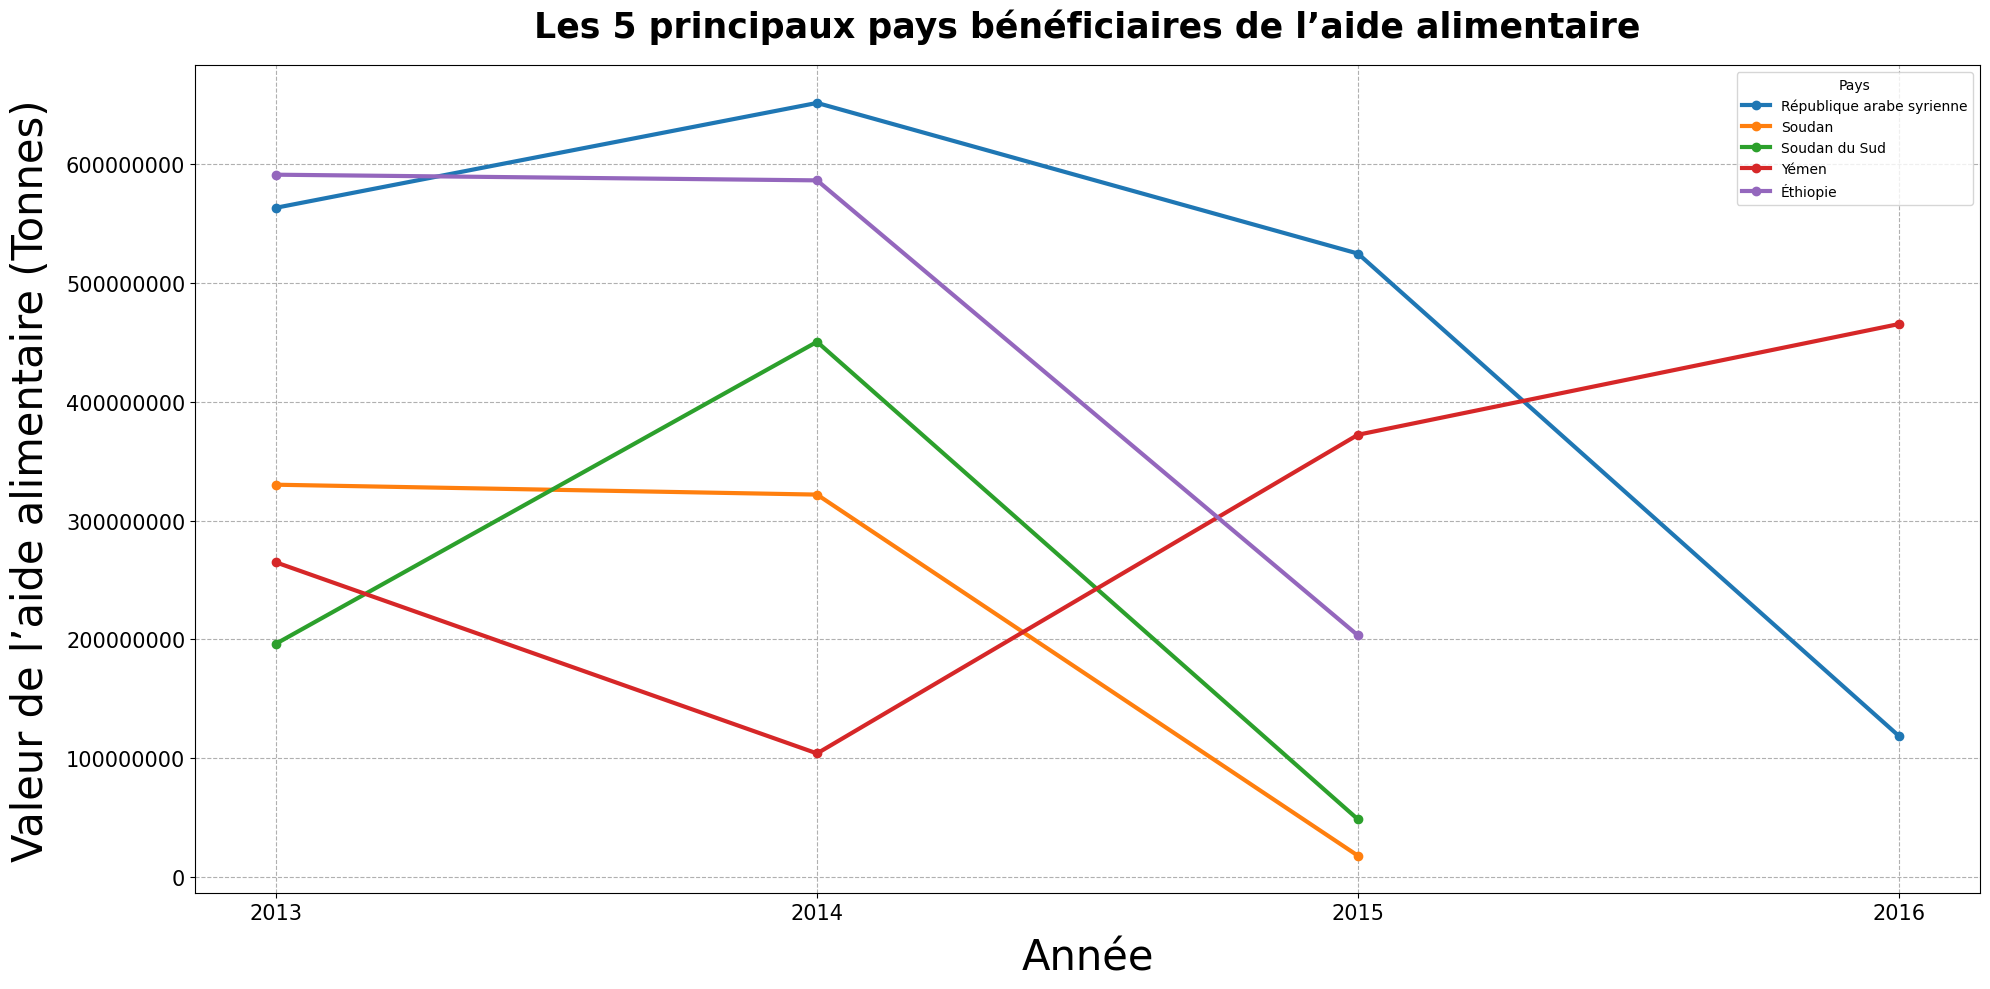

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
for Zone in aide_top5['Zone'].unique():
  df=aide_top5.loc[aide_top5['Zone']==Zone,:]
  plt.plot(df['Année'],df['Valeur'], marker='o',linewidth=3,label=Zone)
plt.legend(title="Pays")
plt.xlabel("Année",fontsize=30,labelpad=10)
plt.ylabel("Valeur de l’aide alimentaire (Tonnes)",fontsize=30,labelpad=10)
plt.xticks(sorted(aide_top5['Année'].unique()),fontsize=15)
plt.yticks(fontsize=15)
plt.title("Les 5 principaux pays bénéficiaires de l’aide alimentaire", fontsize=25,pad=20, fontweight='bold')
plt.grid(True, linestyle='--')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [56]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_alimentaire_pays=dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum()

In [57]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
dispo_alimentaire_pays_moins=dispo_alimentaire_pays.sort_values().reset_index().head(10)
dispo_alimentaire_pays_moins

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,République centrafricaine,1879.0
1,Zambie,1924.0
2,Madagascar,2056.0
3,Afghanistan,2087.0
4,Haïti,2089.0
5,République populaire démocratique de Corée,2093.0
6,Tchad,2109.0
7,Zimbabwe,2113.0
8,Ouganda,2126.0
9,Éthiopie,2129.0


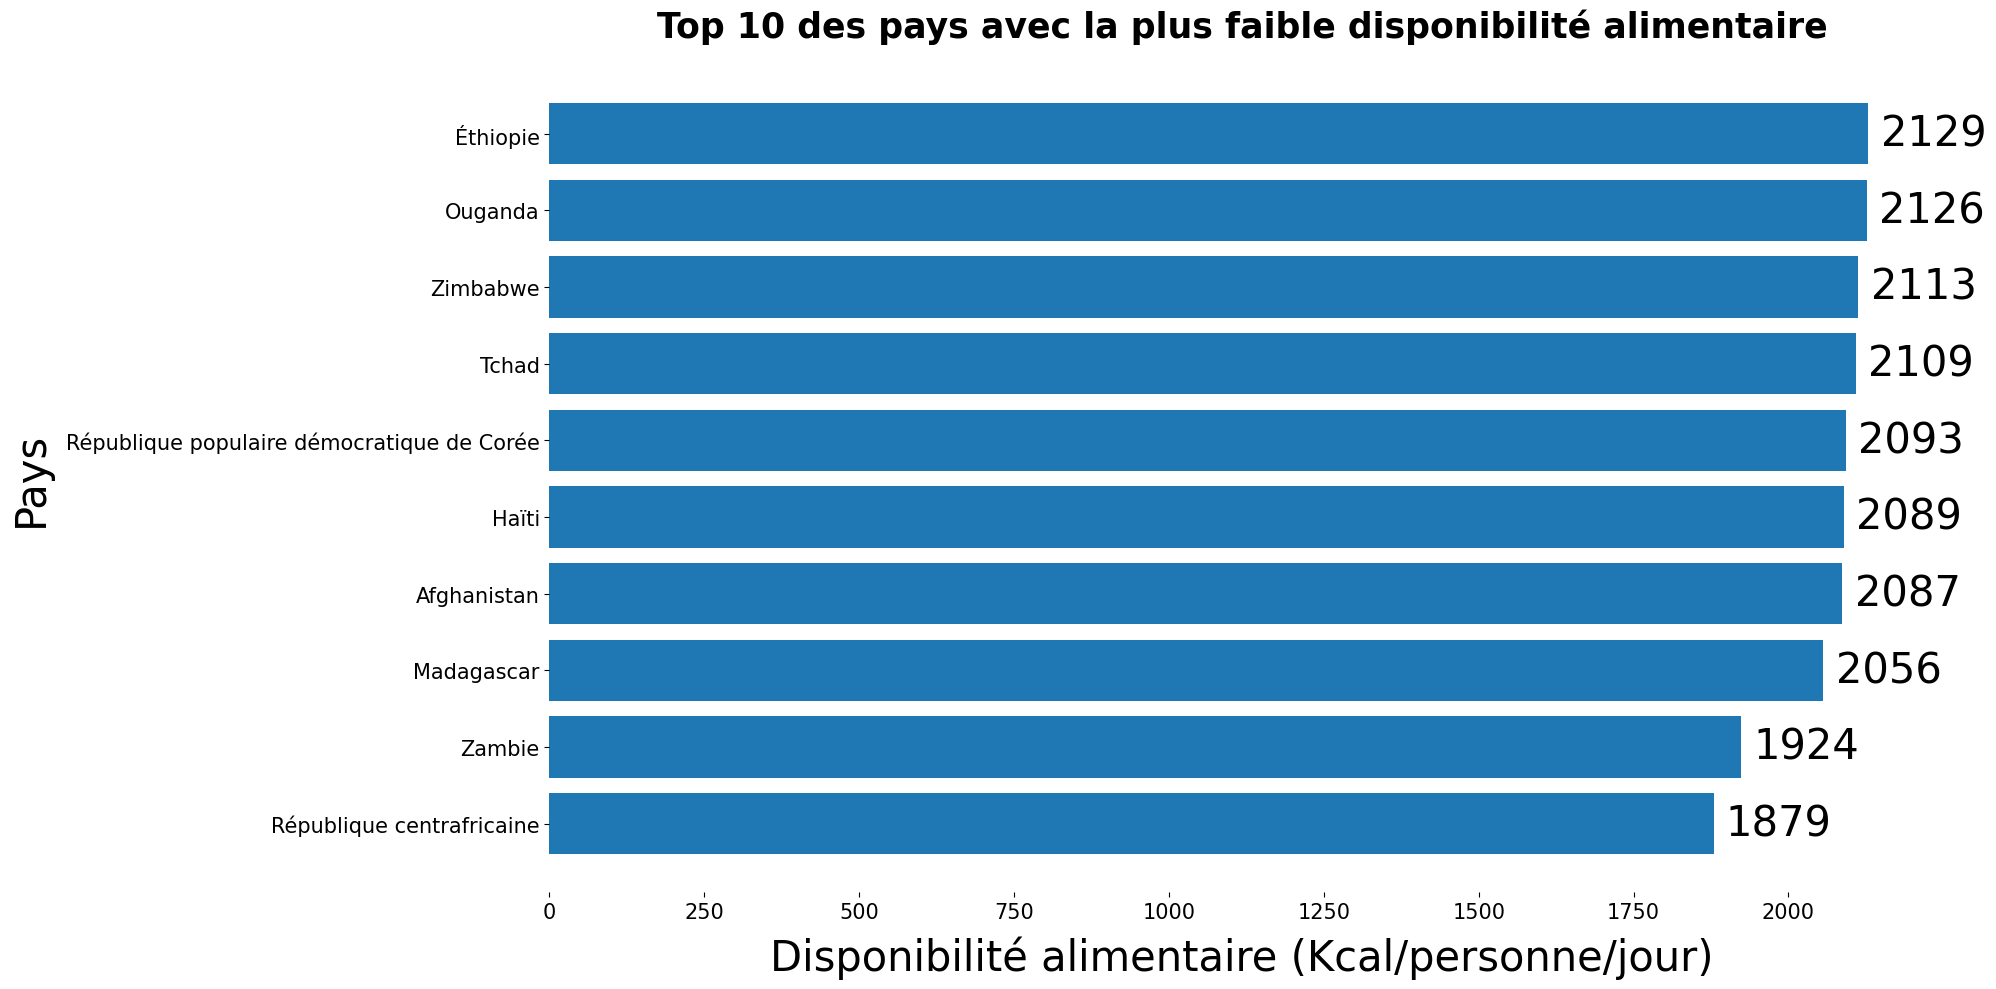

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.barh(y=dispo_alimentaire_pays_moins['Zone'],
         width=dispo_alimentaire_pays_moins['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)", fontsize=30,labelpad=10)
plt.ylabel("Pays", fontsize=30,labelpad=10)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("Top 10 des pays avec la plus faible disponibilité alimentaire", fontsize=25,pad=20, fontweight='bold')
# Affichage des valeurs à droite des barres
for i, v in enumerate(dispo_alimentaire_pays_moins['Disponibilité alimentaire (Kcal/personne/jour)']):
    plt.text(v + 20, i, f"{v:.0f}", va='center', fontsize=30)
# Suppression des bordures
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [59]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
dispo_alimentaire_pays_top=dispo_alimentaire_pays.sort_values(ascending=False).reset_index().head(10)
dispo_alimentaire_pays_top=dispo_alimentaire_pays_top.sort_values('Disponibilité alimentaire (Kcal/personne/jour)',ascending=True)
dispo_alimentaire_pays_top


,Zone,Disponibilité alimentaire (Kcal/personne/jour)
9,Allemagne,3503.0
8,Égypte,3518.0
7,Luxembourg,3540.0
6,Italie,3578.0
5,Irlande,3602.0
4,Israël,3610.0
3,États-Unis d'Amérique,3682.0
2,Turquie,3708.0
1,Belgique,3737.0
0,Autriche,3770.0


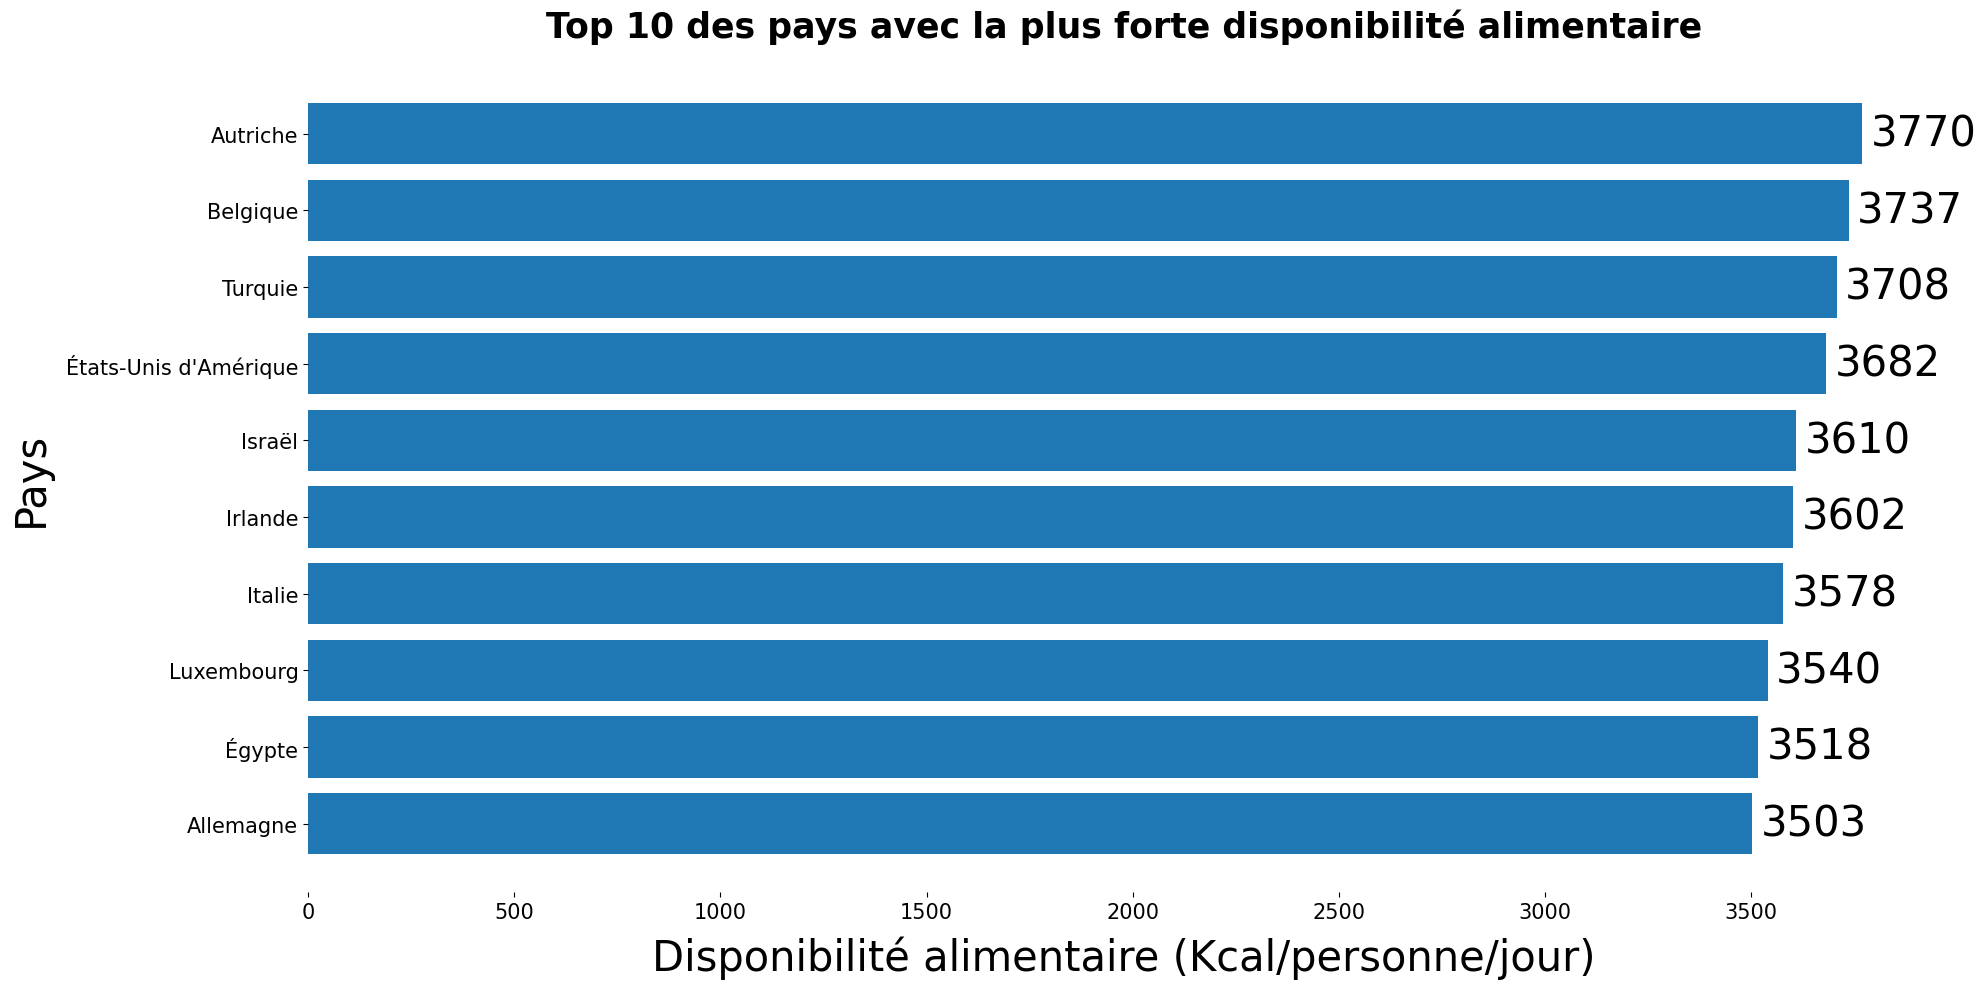

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.barh(y=dispo_alimentaire_pays_top['Zone'],
         width=dispo_alimentaire_pays_top['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)", fontsize=30,labelpad=10)
plt.ylabel("Pays", fontsize=30,labelpad=10)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("Top 10 des pays avec la plus forte disponibilité alimentaire", fontsize=25,pad=20, fontweight='bold')
# Affichage des valeurs à droite des barres
for i, v in enumerate(dispo_alimentaire_pays_top['Disponibilité alimentaire (Kcal/personne/jour)']):
    plt.text(v + 20, i, f"{v:.0f}", va='center', fontsize=30)
# Suppression des bordures
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [61]:
#création d'un dataframe avec uniquement la Thaïlande
Df_thailande=jointure_pop_sous_nutrition.loc[jointure_pop_sous_nutrition['Zone']=='Thaïlande']
Df_thailande


,Zone,Année,Population,Sous_nutrition,Proportion_sous_nutrition
185,Thaïlande,2017,69209810.0,6200000.0,8.958268


In [62]:
#Calcul de la proportion en sous nutrition en Thaïlande
Psous_nutrition=round(Df_thailande['Proportion_sous_nutrition'],2).values[0]
print(' La proportion en sous nutrition en Thaïlande est de', Psous_nutrition,' %')

 La proportion en sous nutrition en Thaïlande est de 8.96  %


In [63]:
# On calcule la proportion exportée en fonction de la proportion
dispo_alimentaire_thailande_manioc=dispo_alimentaire.loc[(dispo_alimentaire['Zone']=='Thaïlande')&(dispo_alimentaire['Produit']=='Manioc'),:]
proportion_exportée_manioc=round(dispo_alimentaire_thailande_manioc['Exportations - Quantité']*100 / dispo_alimentaire_thailande_manioc['Production'],2).values[0]
print('La proportion exportée du manioc en Thaïlande est de ',proportion_exportée_manioc,' %')


La proportion exportée du manioc en Thaïlande est de  83.41  %


In [64]:
# On calcule la disponibilité alimentaire par personne en Thailande
dispo_alimentaire_thailande=dispo_alimentaire.loc[(dispo_alimentaire['Zone']=='Thaïlande'),:]
c=dispo_alimentaire_thailande['Disponibilité alimentaire (Kcal/personne/jour)'].sum()
print('La disponibilité alimentaire par personne en Thailande est de',c,'Kcal')

La disponibilité alimentaire par personne en Thailande est de 2785.0 Kcal


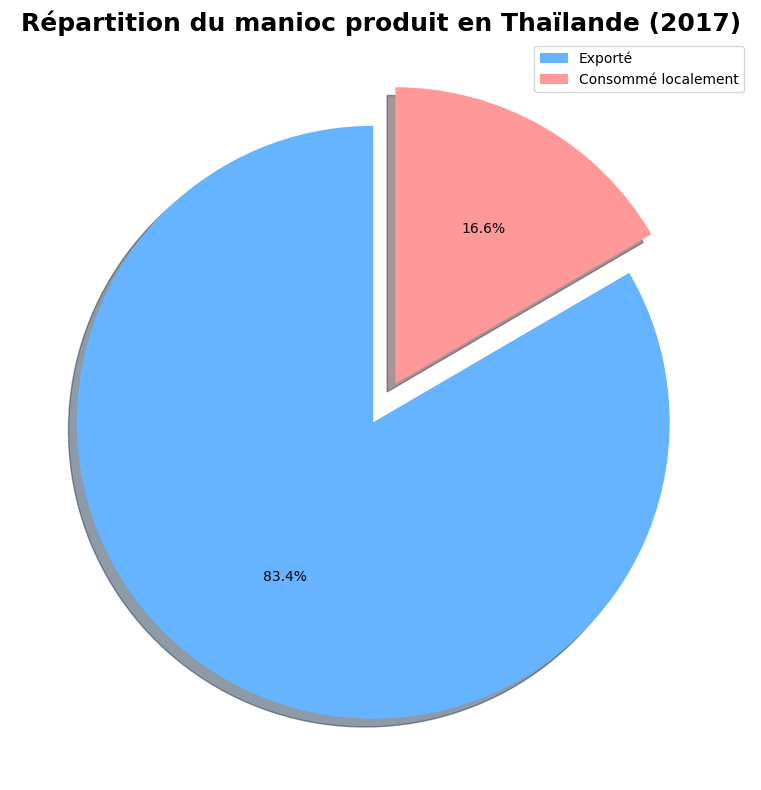

In [65]:
import matplotlib.pyplot as plt
labels = ['Exporté', 'Consommé localement']
Consommé_localement=100-proportion_exportée_manioc
sizes = [proportion_exportée_manioc, Consommé_localement]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.1)
# Création du graphique en secteur
plt.figure(figsize=(8,8))
plt.pie(sizes,autopct='%1.1f%%',startangle=90,colors=colors,explode=explode,shadow=True)
plt.legend(labels)
plt.title("Répartition du manioc produit en Thaïlande (2017)", fontsize=18,fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [66]:
#Analyse du lien entre aide alimentaire et sous nutrition
# Il faut faire une jointure entre la table population et la table sous nutrition
def contient_annee(intervalle, annee):
    debut, fin = intervalle.split('-')
    return int(debut) < annee < int(fin)

# Filtrer les lignes où l'année 2013 est incluse
sous_2013 = sous_nutrition[sous_nutrition['Année'].apply(contient_annee,args=(2013,))].copy()
sous_2013['Année'] = 2013
sous_2013.head()

,Zone,Année,Sous_nutrition
0,Afghanistan,2013,8600000.0
6,Afrique du Sud,2013,2200000.0
12,Albanie,2013,100000.0
18,Algérie,2013,1300000.0
24,Allemagne,2013,0.0


In [67]:
sous_2014 = sous_nutrition[sous_nutrition['Année'].apply(contient_annee,args=(2014,))].copy()
sous_2014['Année'] = 2014

In [68]:
sous_2015 = sous_nutrition[sous_nutrition['Année'].apply(contient_annee,args=(2015,))].copy()
sous_2015['Année'] = 2015

In [69]:
sous_2016 = sous_nutrition[sous_nutrition['Année'].apply(contient_annee,args=(2016,))].copy()
sous_2016['Année'] = 2016

In [70]:
# Fusionner verticalement (ajouter les lignes les unes sous les autres)
sous_2013_2014_2015_2016 = pd.concat([sous_2013, sous_2014, sous_2015, sous_2016], ignore_index=True)
sous_2013_2014_2015_2016=sous_2013_2014_2015_2016.groupby(['Zone','Année'])['Sous_nutrition'].sum().reset_index()
sous_2013_2014_2015_2016.head()

,Zone,Année,Sous_nutrition
0,Afghanistan,2013,8600000.0
1,Afghanistan,2014,8800000.0
2,Afghanistan,2015,8900000.0
3,Afghanistan,2016,9700000.0
4,Afrique du Sud,2013,2200000.0


In [71]:
aide_alimentaireg=aide_alimentaire.groupby(['Zone','Année'])['Valeur'].sum().reset_index()
aide_alimentaireg.head()

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [72]:
#Jointure entre la table aide alimentaire et la table sous nutrition
jointure_aide_sous_nutrition=pd.merge(aide_alimentaireg,sous_2013_2014_2015_2016,on=['Zone','Année'],how='outer')
jointure_aide_sous_nutrition.head()

,Zone,Année,Valeur,Sous_nutrition
0,Afghanistan,2013,128238000.0,8600000.0
1,Afghanistan,2014,57214000.0,8800000.0
2,Afghanistan,2015,NaN,8900000.0
3,Afghanistan,2016,NaN,9700000.0
4,Afrique du Sud,2013,NaN,2200000.0


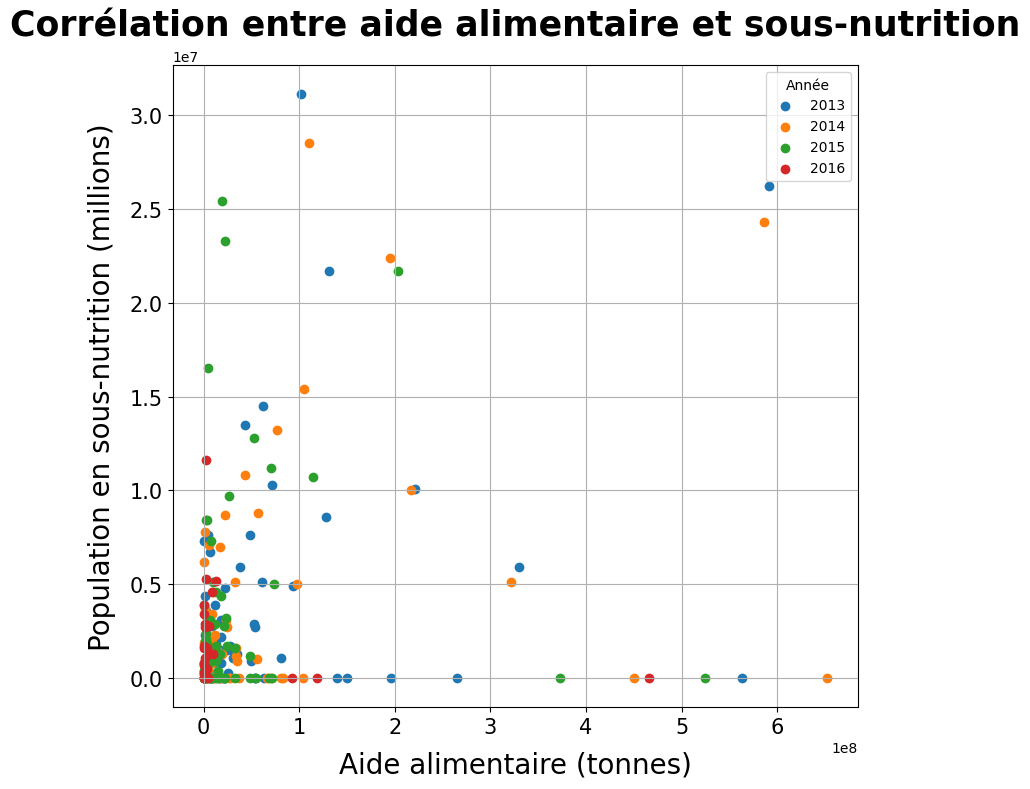

In [73]:
plt.figure(figsize=(8,8))

# Boucle sur les années pour tracer un nuage de points par couleur
for Année in jointure_aide_sous_nutrition['Année'].unique():
  df=jointure_aide_sous_nutrition.loc[jointure_aide_sous_nutrition['Année']==Année,:]
  plt.scatter(df['Valeur'], df['Sous_nutrition'],label=Année)

plt.xlabel("Aide alimentaire (tonnes)", fontsize=20,labelpad=10)
plt.ylabel("Population en sous-nutrition (millions)",fontsize=20,labelpad=10)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("Corrélation entre aide alimentaire et sous-nutrition",fontsize=25,fontweight='bold',pad=10)
plt.grid(True)
plt.legend(title='Année')
plt.tight_layout()
plt.show()